In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
        "2024-03-01 05:00:00",  # ini train
        "2024-03-17 00:00:00",  # end train (último X antes da validação)
        "2024-03-18 05:00:00",  # ini val (começa logo após o último treino)
        "2024-03-31 00:00:00",  # end val (último X antes do teste)
        "2024-04-01 05:00:00",  # ini test (começa logo após a validação)
        "2024-05-10 00:00:00",  # end test

('2024-05-10 00:00:00',)

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

In [26]:
def load_datasets(filepath):
    """Carrega os datasets de arquivos pickle."""
    try:
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        return dataset
    except IOError as e:
        log.error(f"Erro ao carregar o dataset: {e}")
    except pickle.PickleError as e:
        log.error(f"Erro ao desserializar o dataset: {e}")
        traceback.print_exception(e)

In [4]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [5]:
serie = sb["125960550"]

In [6]:
total_points = sb.shape[0]
t = np.arange(total_points)

In [7]:
limite_marco = 31 * 40
limite_abril = limite_marco + (30 * 40)
limite_marco, limite_abril

(1240, 2440)

In [8]:
future_steps = sb.shape[0] - limite_marco
future_steps

2400

In [9]:
sb["125960550"][limite_marco:].shape

(2400,)

In [10]:
input_size = 40 * 7  # tamanho da janela de entrada
train_points = limite_marco  # 1 mês
future_steps = future_steps  
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
def create_windows(data, input_size):
    X, y = [], []
    for i in range(len(data) - input_size):
        X.append(data[i:i+input_size])
        y.append(data[i+input_size])
    return np.array(X), np.array(y)

In [12]:

X_train, y_train = create_windows(serie[:train_points], input_size)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

In [13]:
X_train.shape, y_train.shape

(torch.Size([960, 280]), torch.Size([960, 1]))

## Model

In [15]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [16]:
# --- 5. TREINAMENTO
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/500, Loss: 52.6208
Epoch 20/500, Loss: 35.1840
Epoch 30/500, Loss: 26.8608
Epoch 40/500, Loss: 19.2031
Epoch 50/500, Loss: 13.5167
Epoch 60/500, Loss: 10.2192
Epoch 70/500, Loss: 8.6459
Epoch 80/500, Loss: 7.5996
Epoch 90/500, Loss: 6.7256
Epoch 100/500, Loss: 5.9969
Epoch 110/500, Loss: 5.3584
Epoch 120/500, Loss: 4.8027
Epoch 130/500, Loss: 4.3171
Epoch 140/500, Loss: 3.9117
Epoch 150/500, Loss: 3.5762
Epoch 160/500, Loss: 3.2979
Epoch 170/500, Loss: 3.0678
Epoch 180/500, Loss: 2.8678
Epoch 190/500, Loss: 2.6866
Epoch 200/500, Loss: 2.5157
Epoch 210/500, Loss: 2.3568
Epoch 220/500, Loss: 2.2131
Epoch 230/500, Loss: 2.0808
Epoch 240/500, Loss: 1.9564
Epoch 250/500, Loss: 1.8416
Epoch 260/500, Loss: 1.7376
Epoch 270/500, Loss: 1.6433
Epoch 280/500, Loss: 1.5568
Epoch 290/500, Loss: 1.4792
Epoch 300/500, Loss: 1.4110
Epoch 310/500, Loss: 1.3568
Epoch 320/500, Loss: 1.2979
Epoch 330/500, Loss: 1.2568
Epoch 340/500, Loss: 1.2325
Epoch 350/500, Loss: 1.1849
Epoch 360/500, Loss: 1.

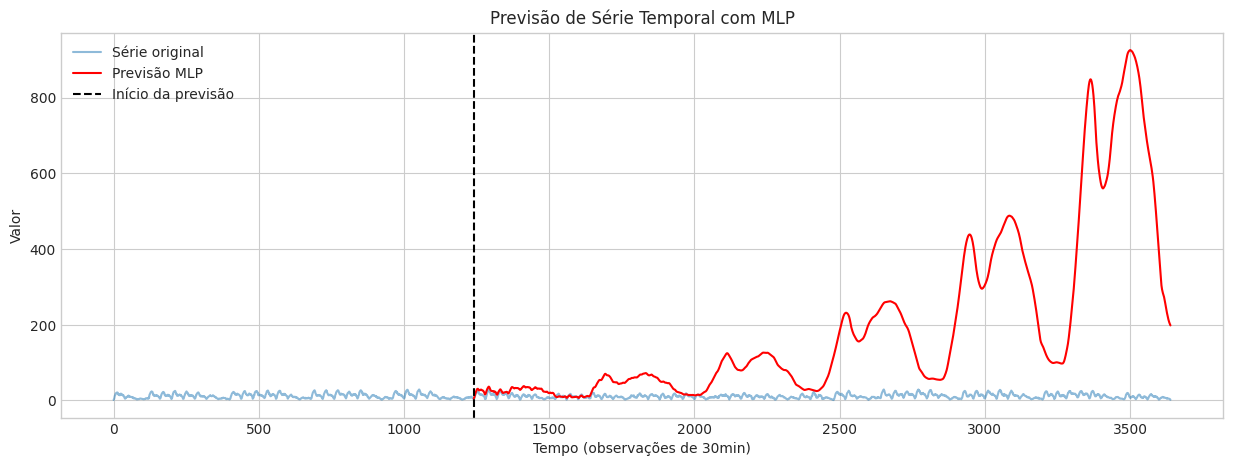

In [17]:
model.eval()
history = list(serie[:train_points])  # Começa com o primeiro mês
predictions = []

for _ in range(future_steps):
    x_input = torch.tensor(history[-input_size:], dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_input).item()
    predictions.append(pred)
    history.append(pred)  # feedback do próprio modelo

# --- 7. PLOT
plt.figure(figsize=(15,5))
plt.plot(t, serie, label="Série original", alpha=0.5)
plt.plot(t[train_points:train_points+future_steps], predictions, label="Previsão MLP", color="r")
plt.axvline(x=train_points, color='k', linestyle='--', label="Início da previsão")
plt.legend()
plt.title("Previsão de Série Temporal com MLP")
plt.xlabel("Tempo (observações de 30min)")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

## Forecasting in batch

In [21]:
nodes = [53,  365,  382,  666,  701, 1326, 1404, 1569, 1916, 2617]

In [22]:
stops = {53: '125960550',
         365: '230565994',
         382: '258781031',
         666: '43768720',
         701: '44072192',
         1326: '44783654',
         1404: '44783914',
         1569: '44784438',
         1916: '45833547',
         2617: '47568123'}

In [27]:
fpath_root = "/mnt/data/marcos/data/node_regression_bus/data_split/"
test_dataset = load_datasets(f'{fpath_root}test.pkl')
# x (dados de input)
test_dataset[0].x.shape

torch.Size([2871, 280])

In [52]:
a = [1,2, 3]
a

[1, 2, 3]

In [53]:
b = [0,0,0]
b[0:-1] = a[1:]
b

[2, 3, 0]

In [64]:
scores_error = {'node': [], 'batch': [], 'mae': [], 'mse': [], 'r2': [], 'mape': []}
targets = []
cost, time = 0, 0
dfs = []


for node in nodes:
    dfs_pred = []    
    for time, snapshot in tqdm(enumerate(test_dataset)):
        snapshot.to('cuda')
        predictions = []
        #
        # (alterar aqui o modelo)
        #
        y_true = snapshot.y.cpu().data.numpy()
        x_input = torch.tensor(snapshot.x[node,:])
        for j in range(y_true.shape[1]):
            
            with torch.no_grad():
                pred = model(x_input).item()

            # Atualiza o input com o valor predito (lag)
            x_input = x_input.squeeze(0)
            x_input[:-1] = x_input[1:].clone()  # <-- clone aqui é essencial
            x_input[-1] = pred
            x_input = x_input.unsqueeze(0)  # mantém formato [1, features]
                               
            predictions.append(pred)

        y_pred = np.array(predictions)
        y_true = y_true[node,:]
        
        # nao alterar mais abaixo
        
        scores_error['node'].append(stops[node])
        scores_error['batch'].append(time)
        scores_error['mse'].append(mean_squared_error(y_true, y_pred))
        scores_error['mae'].append(mean_absolute_error(y_true, y_pred))
        scores_error['r2'].append(r2_score(y_true, y_pred))
        scores_error['mape'].append(mean_absolute_percentage_error(y_true, y_pred))
        
        targets.append({'true': y_true,
                        'pred': y_pred})
        
        

38it [00:01, 25.82it/s]
38it [00:01, 25.83it/s]
38it [00:01, 25.81it/s]
38it [00:01, 25.83it/s]
38it [00:01, 25.62it/s]
38it [00:01, 25.86it/s]
38it [00:01, 25.83it/s]
38it [00:01, 25.86it/s]
38it [00:01, 25.87it/s]
38it [00:01, 25.85it/s]


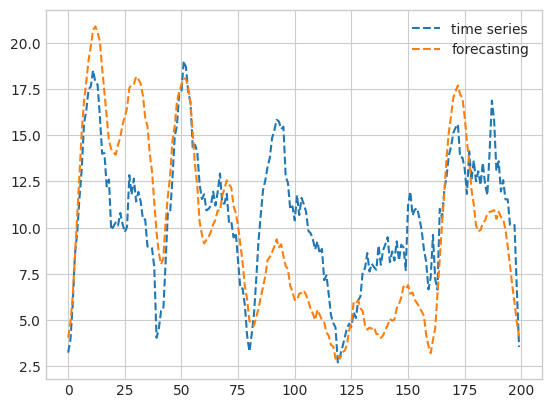

In [66]:
plt.plot(targets[10]["true"], '--', label="time series")
plt.plot(targets[10]["pred"], '--', label="forecasting")
plt.legend()
plt.show()

In [67]:
df_results = pd.DataFrame(scores_error)
df_results

,node,batch,mae,mse,r2,mape
0,125960550,0,9.315366,110.852805,-6.645981,1.010148
1,125960550,1,7.719656,75.548898,-4.551847,0.842993
2,125960550,2,17.330191,328.927969,-22.088893,2.197176
3,125960550,3,2.223090,8.417102,0.443286,0.229237
4,125960550,4,2.369555,9.244600,0.298128,0.241542
...,...,...,...,...,...,...
375,47568123,33,27.312124,1157.600789,0.674645,0.297802
376,47568123,34,39.470575,2433.473202,0.364138,0.370398
377,47568123,35,63.078815,5483.186522,-1.136708,0.529145
378,47568123,36,72.220391,8502.257099,-1.934563,0.758503


In [68]:
df_results.pivot_table(index=["node"], 
                       values=["mae", "mse", "r2", "mape"], 
                       aggfunc="mean").reset_index()

,node,mae,mape,mse,r2
0,125960550,4.587343,0.473544,4.255646e+01,-0.995734
1,230565994,28.249685,3.088489,1.253684e+03,-4.172451
2,258781031,604.203812,0.869919,7.398252e+05,-2.588535
3,43768720,1332.324728,1.520615,3.387351e+06,-5.171187
4,44072192,122.354322,2.100908,2.859728e+04,-8.273083
5,44783654,198.904256,1.834229,6.977763e+04,-4.376165
6,44783914,373.289519,2.419930,2.386381e+05,-6.201942
7,44784438,201.316862,1.665382,7.197686e+04,-3.856163
8,45833547,93.212365,3.187456,1.500943e+04,-5.480563
9,47568123,78.150150,0.945373,1.105223e+04,-2.314449


In [69]:
df_results["mae"].mean(), df_results["mape"].mean(), df_results["mse"].mean(), df_results["r2"].mean()

(303.65930415434894,
 1.8105845381446306,
 456352.40874671063,
 -4.343027334424497)